In [79]:
import pandas as pd #dataframe and series
import numpy as np #scientific computing packages-Array

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline


# Spotify song attributes EDA

-import dataset
-EDA to visualize data andd observe structutre
-Train a classifier(Decision tree)
-Predict the traget using the classifier

In [82]:
data = pd.read_csv(r'C:\Users\pramo\OneDrive\Desktop\AIML\data.csv')

In [84]:
type(data)

pandas.core.frame.DataFrame

In [86]:
data.describe()

,Unnamed: 0,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,target
count,2017.000000,2017.000000,2017.000000,2.017000e+03,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000,2017.000000
mean,1008.000000,0.187590,0.618422,2.463062e+05,0.681577,0.133286,5.342588,0.190844,-7.085624,0.612295,0.092664,121.603272,3.968270,0.496815,0.505702
std,582.402066,0.259989,0.161029,8.198181e+04,0.210273,0.273162,3.648240,0.155453,3.761684,0.487347,0.089931,26.685604,0.255853,0.247195,0.500091
min,0.000000,0.000003,0.122000,1.604200e+04,0.014800,0.000000,0.000000,0.018800,-33.097000,0.000000,0.023100,47.859000,1.000000,0.034800,0.000000
25%,504.000000,0.009630,0.514000,2.000150e+05,0.563000,0.000000,2.000000,0.092300,-8.394000,0.000000,0.037500,100.189000,4.000000,0.295000,0.000000
50%,1008.000000,0.063300,0.631000,2.292610e+05,0.715000,0.000076,6.000000,0.127000,-6.248000,1.000000,0.054900,121.427000,4.000000,0.492000,1.000000
75%,1512.000000,0.265000,0.738000,2.703330e+05,0.846000,0.054000,9.000000,0.247000,-4.746000,1.000000,0.108000,137.849000,4.000000,0.691000,1.000000
max,2016.000000,0.995000,0.984000,1.004627e+06,0.998000,0.976000,11.000000,0.969000,-0.307000,1.000000,0.816000,219.331000,5.000000,0.992000,1.000000


In [88]:
data.head()

,Unnamed: 0,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,target,song_title,artist
0,0,0.0102,0.833,204600,0.434,0.021900,2,0.1650,-8.795,1,0.4310,150.062,4.0,0.286,1,Mask Off,Future
1,1,0.1990,0.743,326933,0.359,0.006110,1,0.1370,-10.401,1,0.0794,160.083,4.0,0.588,1,Redbone,Childish Gambino
2,2,0.0344,0.838,185707,0.412,0.000234,2,0.1590,-7.148,1,0.2890,75.044,4.0,0.173,1,Xanny Family,Future
3,3,0.6040,0.494,199413,0.338,0.510000,5,0.0922,-15.236,1,0.0261,86.468,4.0,0.230,1,Master Of None,Beach House
4,4,0.1800,0.678,392893,0.561,0.512000,5,0.4390,-11.648,0,0.0694,174.004,4.0,0.904,1,Parallel Lines,Junior Boys


In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2017 entries, 0 to 2016
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        2017 non-null   int64  
 1   acousticness      2017 non-null   float64
 2   danceability      2017 non-null   float64
 3   duration_ms       2017 non-null   int64  
 4   energy            2017 non-null   float64
 5   instrumentalness  2017 non-null   float64
 6   key               2017 non-null   int64  
 7   liveness          2017 non-null   float64
 8   loudness          2017 non-null   float64
 9   mode              2017 non-null   int64  
 10  speechiness       2017 non-null   float64
 11  tempo             2017 non-null   float64
 12  time_signature    2017 non-null   float64
 13  valence           2017 non-null   float64
 14  target            2017 non-null   int64  
 15  song_title        2017 non-null   object 
 16  artist            2017 non-null   object 


In [92]:
train ,test=train_test_split(data, test_size=0.15)

In [94]:
print("Training size :  {}; Test size : {}".format(len(train),len(test)))

Training size :  1714; Test size : 303


In [96]:
#custom color palette
red_blue=["#19B5FE","#EF4836"]
palette=sns.color_palette(red_blue)
sns.set_palette(palette)
sns.set_style("white")

In [98]:
pos_tempo=data[data['target']==1]['tempo']
neg_tempo=data[data['target']==0]['tempo']

pos_dance=data[data['target']==1]['danceability']
neg_dance=data[data['target']==0]['danceability']

pos_duration=data[data['target']==1]['duration_ms']
neg_duration=data[data['target']==0]['duration_ms']

pos_loudness=data[data['target']==1]['loudness']
neg_loudness=data[data['target']==0]['loudness']

pos_speechiness=data[data['target']==1]['speechiness']
neg_speechiness=data[data['target']==0]['speechiness']

pos_valence=data[data['target']==1]['valence']
neg_valence=data[data['target']==0]['valence']

pos_acousticness=data[data['target']==1]['acousticness']
neg_acousticness=data[data['target']==0]['acousticness']

pos_energy=data[data['target']==1]['energy']
neg_energy=data[data['target']==0]['energy']

pos_key=data[data['target']==1]['key']
neg_key=data[data['target']==0]['key']

pos_instrumentalness=data[data['target']==1]['instrumentalness']
neg_instrumentalness=data[data['target']==0]['instrumentalness']

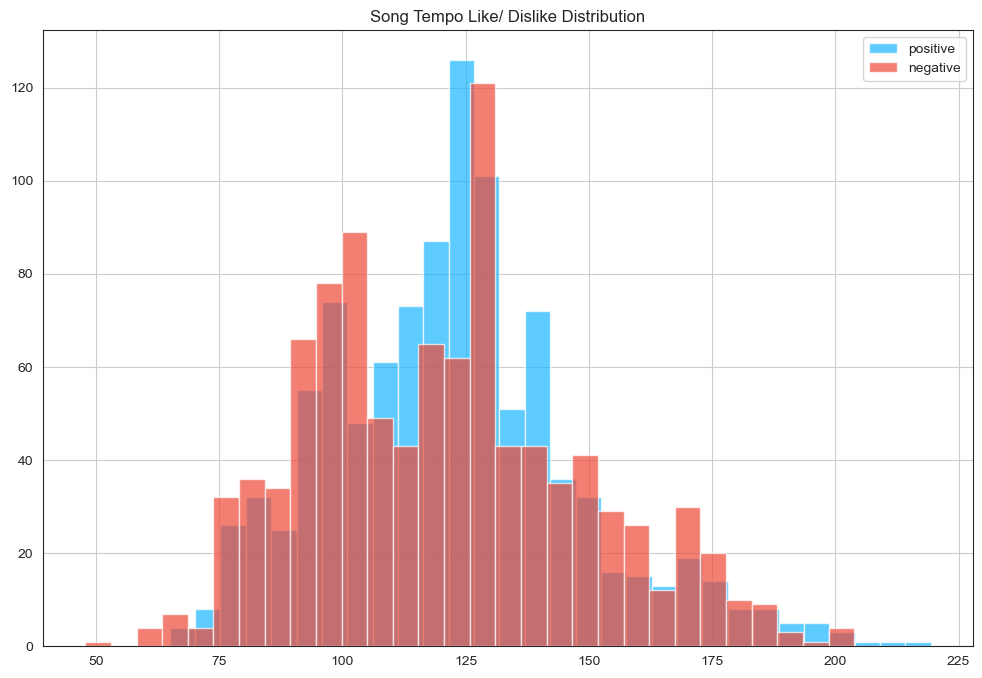

In [100]:
pos_tempo=data[data['target']==1]['tempo']
neg_tempo=data[data['target']==0]['tempo']


fig=plt.figure(figsize=(12,8))
plt.title("Song Tempo Like/ Dislike Distribution")
pos_tempo.hist(alpha=0.7,bins= 30,label='positive')
neg_tempo.hist(alpha=0.7,bins= 30,label='negative')
plt.legend(loc="upper right")

plt.show()


In [101]:
pos_tempo

0       150.062
1       160.083
2        75.044
3        86.468
4       174.004
         ...   
1015    139.997
1016     86.733
1017    140.008
1018    147.072
1019    107.039
Name: tempo, Length: 1020, dtype: float64

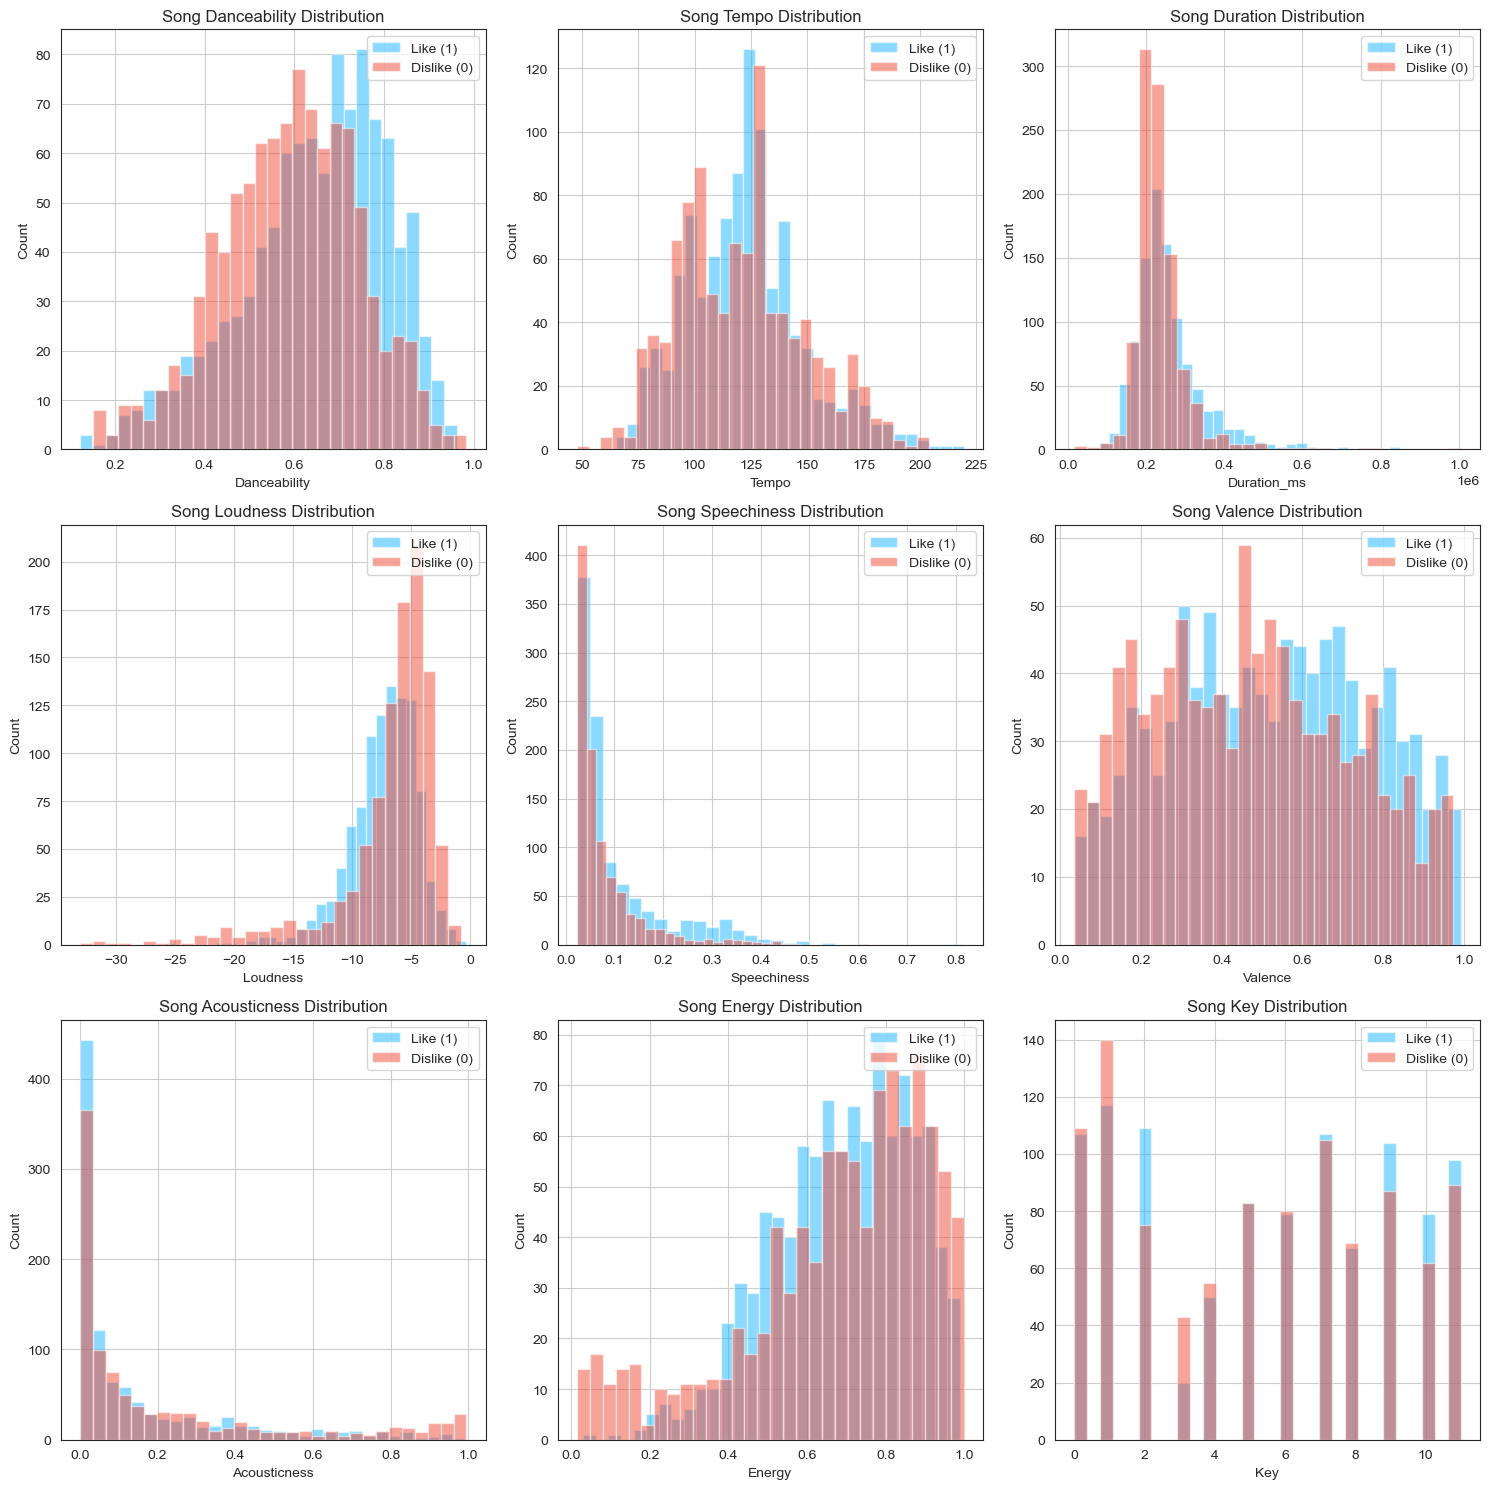

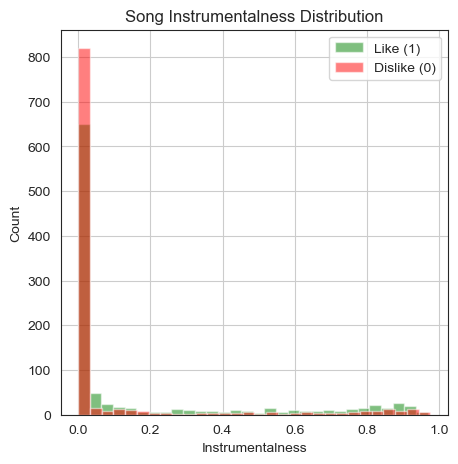

In [102]:
# 1. Group your features into a list of tuples (column_name, display_title)
# This will let us loop through them cleanly instead of copy-pasting code 9 times!
features = [
    ('danceability', 'Song Danceability Distribution'),
    ('tempo', 'Song Tempo Distribution'),
    ('duration_ms', 'Song Duration Distribution'),
    ('loudness', 'Song Loudness Distribution'),
    ('speechiness', 'Song Speechiness Distribution'),
    ('valence', 'Song Valence Distribution'),
    ('acousticness', 'Song Acousticness Distribution'),
    ('energy', 'Song Energy Distribution'),
    ('key', 'Song Key Distribution'),
    ('instrumentalness', 'Song Instrumentalness Distribution')
]

# 2. Create the main 3x3 figure for the first 9 features
fig = plt.figure(figsize=(15, 15))

for i, (col, title) in enumerate(features[:9]):
    # Create subplot dynamically (positions 1 through 9)
    ax = fig.add_subplot(3, 3, i + 1)
    
    # Separate pos and neg based on target directly inside the loop
    pos_data = data[data['target'] == 1][col]
    neg_data = data[data['target'] == 0][col]
    
    # Plot histograms
    pos_data.hist(ax=ax, alpha=0.5, bins=30, label='Like (1)')
    neg_data.hist(ax=ax, alpha=0.5, bins=30, label='Dislike (0)')
    
    # Labels and formatting
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend(loc='upper right')

# Adjust layout so titles and labels don't overlap
plt.tight_layout()
plt.show()

# 3. Create a separate plot for the 10th feature (Instrumentalness) 
# so it doesn't get left out of the 3x3 grid!
fig2 = plt.figure(figsize=(5, 5))
ax_last = fig2.add_subplot(111)

col, title = features[9]
data[data['target'] == 1][col].hist(ax=ax_last, alpha=0.5, bins=30, label='Like (1)', color='green')
data[data['target'] == 0][col].hist(ax=ax_last, alpha=0.5, bins=30, label='Dislike (0)', color='red')

ax_last.set_xlabel(col.capitalize())
ax_last.set_ylabel('Count')
ax_last.set_title(title)
ax_last.legend(loc='upper right')

plt.show()


In [144]:
c=DecisionTreeClassifier(min_samples_split=75)

In [146]:
features=["danceability","loudness","valence","energy","instrumentalness","acousticness","key","speechiness","tempo","duration_ms"]
train, test = train_test_split(data, test_size=0.2, random_state=42)
x_train=train[features]
y_train=train["target"]

x_test=test[features]
y_test=test["target"]

In [148]:
dt=c.fit(x_train,y_train)

In [150]:
!pip install graphviz pydotplus

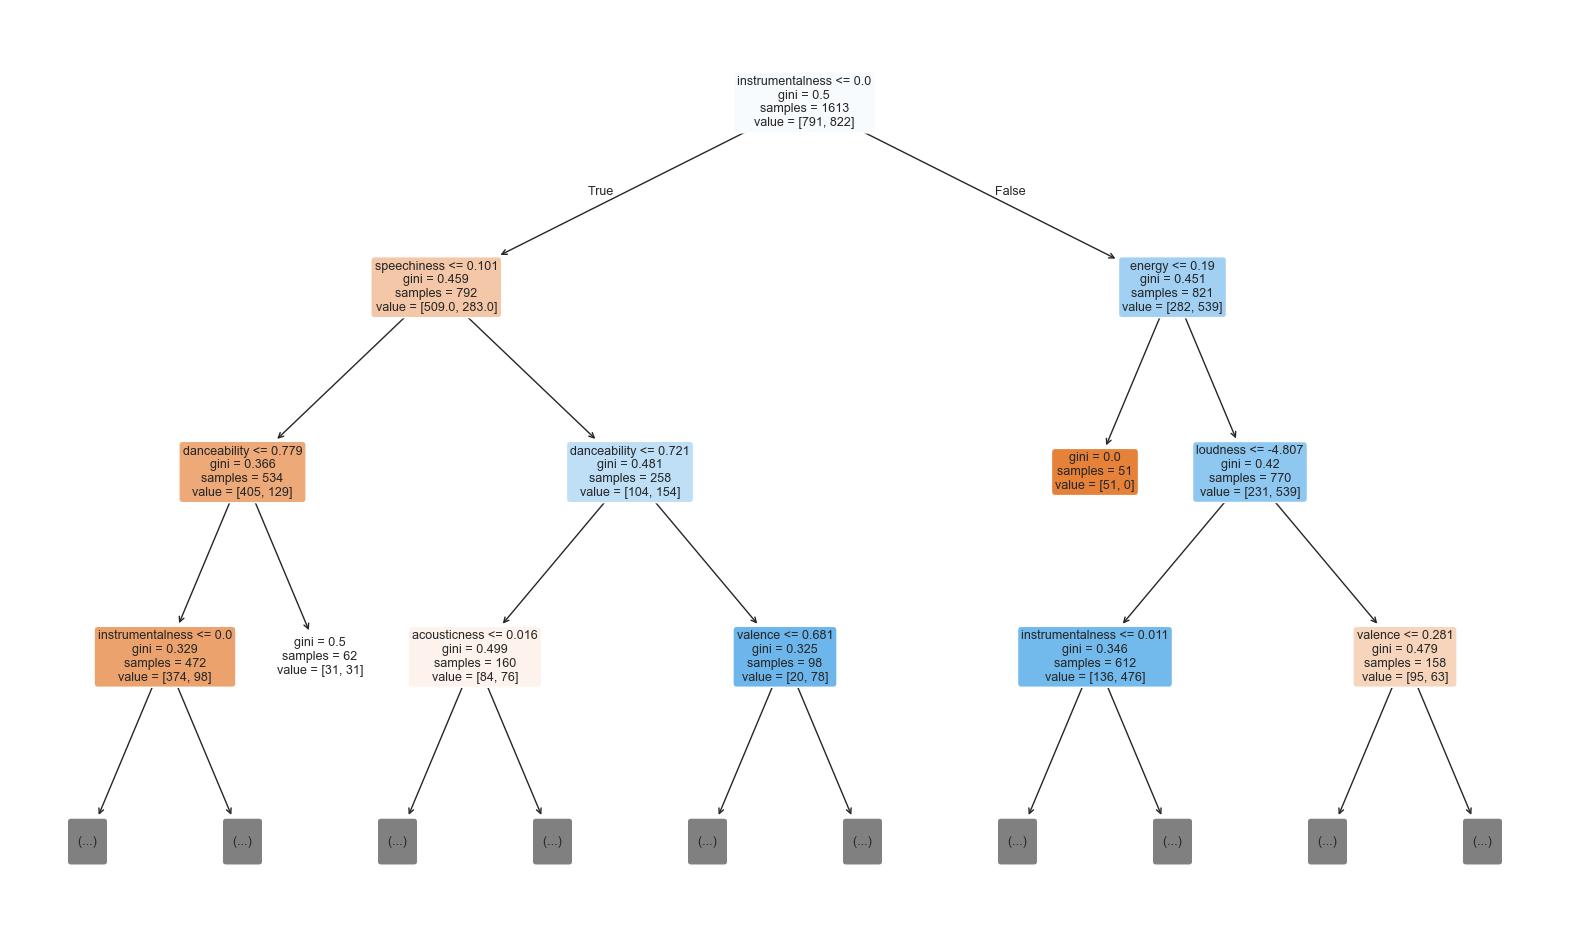

In [151]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Create a clean figure window
fig = plt.figure(figsize=(20, 12))

# Plot the tree directly inside the notebook
# max_depth=3 prevents it from becoming a massive, unreadable blur
plot_tree(dt, feature_names=features, filled=True, rounded=True, max_depth=3)

plt.show()

In [152]:
y_predict=c.predict(x_test)

In [153]:
y_predict

array([0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,

In [154]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_predict)*100

In [155]:
print("Accuracy Using Decision Tree: ", round (score , 1), "%")

Accuracy Using Decision Tree:  70.8 %


In [162]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.1f}%")

Random Forest Accuracy: 75.7%
